In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from keras.datasets import fashion_mnist
import matplotlib.pyplot as plt

In [2]:
(train_data, train_labels), (test_data, test_labels) = fashion_mnist.load_data()

In [3]:
train_data.shape

(60000, 28, 28)

In [4]:
train_labels

array([9, 0, 0, ..., 3, 0, 5], shape=(60000,), dtype=uint8)

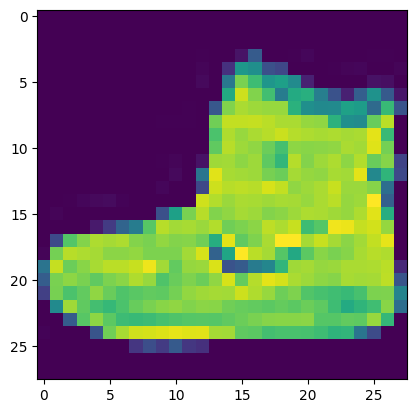

In [5]:
plt.imshow(train_data[0])
# print(train_data[0])

In [6]:
x_train = train_data
y_train = train_labels
x_test = test_data
y_test = test_labels

In [7]:
x_train.shape

(60000, 28, 28)

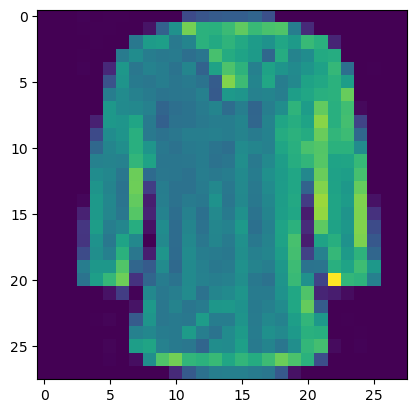

In [7]:
plt.imshow(x_test[4])

In [8]:
# from sklearn.preprocessing import StandardScaler

# sc = StandardScaler()

# x_train = sc.fit_transform(x_train)
# x_test = sc.transform(x_test)

In [9]:
# build model

model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(4, activation='relu'), # input layers
    tf.keras.layers.Dense(4, activation='relu'), # hidden layers
    tf.keras.layers.Dense(10, activation='softmax'), # output layers
])

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

/Users/swagat98/anaconda3/envs/machine-learning/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
model_history = model.fit(x_train, tf.one_hot(y_train,depth=10), epochs=40, validation_data=(x_test, tf.one_hot(y_test, depth=10)))

Epoch 1/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 623us/step - accuracy: 0.0985 - loss: 2.3586 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 2/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 699us/step - accuracy: 0.0980 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 3/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 611us/step - accuracy: 0.0976 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 4/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 573us/step - accuracy: 0.0992 - loss: 2.3027 - val_accuracy: 0.1000 - val_loss: 2.3027
Epoch 5/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 573us/step - accuracy: 0.0984 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 6/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 604us/step - accuracy: 0.1004 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 7/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 567us/step - accuracy: 0.0984 - loss: 2.3027 - val_accuracy: 0.1000 - val_loss: 2.3027
Epoch 8/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 570us/step - accuracy: 0.0966 -

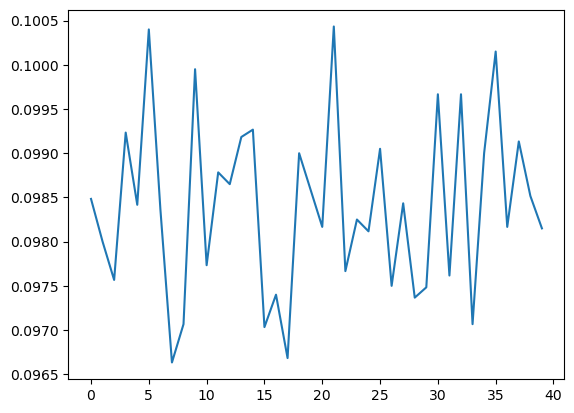

In [11]:
accuracy = model_history.history['accuracy']
len(accuracy)
x = np.arange(0,len(accuracy),1)

plt.plot(x,accuracy)

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         3,140 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │            50 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,632 (37.63 KB)

 Trainable params: 3,210 (12.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,422 (25.09 KB)

In [13]:
x_train.min(),x_train.max()

(np.uint8(0), np.uint8(255))

In [14]:
x_train.shape[0]

60000

In [8]:
x_train = x_train/255.
x_test = x_test/255.

In [9]:
x_train.shape

(60000, 28, 28)

In [12]:
x_train[:,14,14]

array([0.85098039, 0.8       , 0.33333333, ..., 0.88627451, 0.24313725,
       0.        ], shape=(60000,))

In [16]:
model2 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(4,activation='relu'),
    tf.keras.layers.Dense(4,activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model2.compile(optimizer='adam', loss=tf.keras.losses.SparseCategoricalCrossentropy, metrics=['accuracy'])


model_history = model2.fit(x_train, y_train, batch_size=32, epochs=25, validation_data=(x_test, y_test))

Epoch 1/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 801us/step - accuracy: 0.5611 - loss: 1.2079 - val_accuracy: 0.6025 - val_loss: 0.9861
Epoch 2/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 595us/step - accuracy: 0.6765 - loss: 0.8663 - val_accuracy: 0.7343 - val_loss: 0.7986
Epoch 3/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 573us/step - accuracy: 0.7593 - loss: 0.6950 - val_accuracy: 0.7572 - val_loss: 0.6864
Epoch 4/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 683us/step - accuracy: 0.7837 - loss: 0.6210 - val_accuracy: 0.7868 - val_loss: 0.6149
Epoch 5/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 569us/step - accuracy: 0.8034 - loss: 0.5792 - val_accuracy: 0.8021 - val_loss: 0.5873
Epoch 6/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 580us/step - accuracy: 0.8091 - loss: 0.5569 - val_accuracy: 0.8039 - val_loss: 0.5781
Epoch 7/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 667us/step - accuracy: 0.8130 - loss: 0.5433 - val_accuracy: 0.8046 - val_loss: 0.5688
Epoch 8/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 617us/step - accuracy: 0.8154 -

In [17]:
hist = model_history.history
accuracy = hist['accuracy']

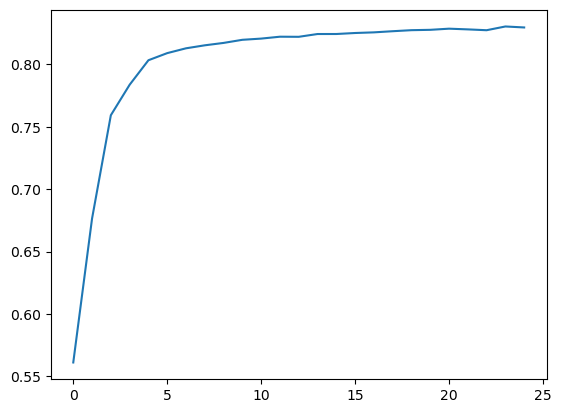

In [18]:
x = np.arange(0, len(accuracy),1)

plt.plot(x,accuracy)

In [19]:
model3 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(4,activation='relu'),
    tf.keras.layers.Dense(4,activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model3.compile(optimizer='adam', loss=tf.keras.losses.SparseCategoricalCrossentropy(), metrics=['accuracy'])


# model_history = model3.fit(x_train, y_train, batch_size=32, epochs=25, validation_data=(x_test, y_test))



lr_scheduler = tf.keras.callbacks.LearningRateScheduler(lambda epochs: 1e-3 * 10**(epochs/20))

find_lr_history  = model3.fit(x_train, y_train, epochs=40, validation_data=(x_test,y_test), callbacks=[lr_scheduler])

Epoch 1/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 702us/step - accuracy: 0.5203 - loss: 1.1797 - val_accuracy: 0.6982 - val_loss: 0.8223 - learning_rate: 0.0010
Epoch 2/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 550us/step - accuracy: 0.7471 - loss: 0.7285 - val_accuracy: 0.7544 - val_loss: 0.6980 - learning_rate: 0.0011
Epoch 3/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 578us/step - accuracy: 0.7677 - loss: 0.6532 - val_accuracy: 0.7617 - val_loss: 0.6655 - learning_rate: 0.0013
Epoch 4/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 634us/step - accuracy: 0.7739 - loss: 0.6278 - val_accuracy: 0.7603 - val_loss: 0.6544 - learning_rate: 0.0014
Epoch 5/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 546us/step - accuracy: 0.7792 - loss: 0.6140 - val_accuracy: 0.7710 - val_loss: 0.6462 - learning_rate: 0.0016
Epoch 6/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 697us/step - accuracy: 0.7831 - loss: 0.6062 - val_accuracy: 0.7570 - val_loss: 0.6832 - learning_rate: 0.0018
Epoch 7/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 559us/step - accura

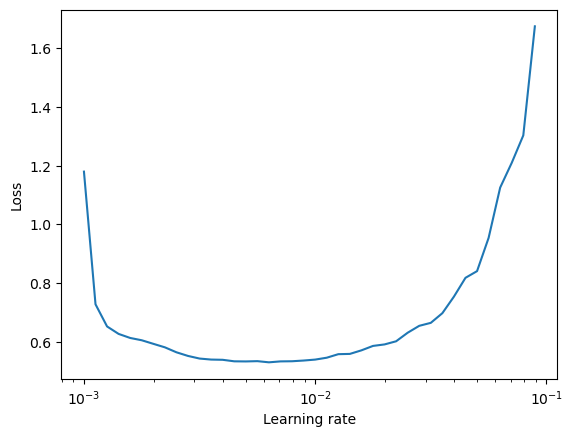

In [20]:
y_axis = find_lr_history.history['accuracy']
y_axis
x_len = len(y_axis)
x_len

lrs = 1e-3 * (10**(tf.range(40)/20))
plt.figure()
plt.semilogx(lrs, find_lr_history.history['loss'])
plt.xlabel('Learning rate')
plt.ylabel('Loss')
plt.show()
# x = np.arange(0,)

In [21]:
import tensorflow as tf

In [23]:
model3 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(4,activation='relu'),
    tf.keras.layers.Dense(4,activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model3.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001)  , loss=tf.keras.losses.SparseCategoricalCrossentropy(), metrics=['accuracy'])


model_history = model3.fit(x_train, y_train, batch_size=32, epochs=25, validation_data=(x_test, y_test))



# lr_scheduler = tf.keras.callbacks.LearningRateScheduler(lambda epochs: 1e-3 * 10**(epochs/20))

# find_lr_history  = model_.fit(x_train, y_train, epochs=40, validation_data=(x_test,y_test), callbacks=[lr_scheduler])

/Users/swagat98/anaconda3/envs/machine-learning/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.5257 - loss: 1.2483 - val_accuracy: 0.6004 - val_loss: 0.9590
Epoch 2/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 856us/step - accuracy: 0.6362 - loss: 0.8731 - val_accuracy: 0.6691 - val_loss: 0.8353
Epoch 3/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 873us/step - accuracy: 0.6954 - loss: 0.7613 - val_accuracy: 0.6983 - val_loss: 0.7511
Epoch 4/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 594us/step - accuracy: 0.7089 - loss: 0.7182 - val_accuracy: 0.7052 - val_loss: 0.7326
Epoch 5/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 618us/step - accuracy: 0.7151 - loss: 0.6988 - val_accuracy: 0.7120 - val_loss: 0.7131
Epoch 6/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 570us/step - accuracy: 0.7195 - loss: 0.6846 - val_accuracy: 0.7180 - val_loss: 0.7101
Epoch 7/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 687us/step - accuracy: 0.7278 - loss: 0.6756 - val_accuracy: 0.7248 - val_loss: 0.6934
Epoch 8/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 581us/step - accuracy: 0.7489 - l

In [29]:
y_pred = model3.predict(x_test)
y_pred

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 328us/step


array([[8.78537798e-10, 7.61526962e-07, 6.35391963e-18, ...,
        4.40274402e-02, 1.16882338e-05, 8.17277551e-01],
       [1.01442244e-02, 1.19615335e-03, 4.57705885e-01, ...,
        5.11211692e-04, 1.96849601e-03, 1.69111195e-03],
       [8.85607384e-04, 9.99114335e-01, 5.46816201e-16, ...,
        0.00000000e+00, 5.78886228e-09, 0.00000000e+00],
       ...,
       [1.83416437e-02, 2.60240934e-03, 6.67953500e-05, ...,
        4.33529587e-03, 4.64044720e-01, 2.19921759e-07],
       [2.15917882e-02, 9.78388131e-01, 2.23438296e-10, ...,
        0.00000000e+00, 1.40873090e-06, 2.68317626e-30],
       [1.90573232e-07, 1.57168222e-06, 1.07942965e-14, ...,
        2.79571638e-02, 3.87390628e-06, 1.86880957e-02]], dtype=float32)

In [30]:
y_pred[:5]

array([[8.7853780e-10, 7.6152696e-07, 6.3539196e-18, 6.0880008e-12,
        3.2156570e-15, 1.3868254e-01, 1.2913851e-13, 4.4027440e-02,
        1.1688234e-05, 8.1727755e-01],
       [1.0144224e-02, 1.1961533e-03, 4.5770589e-01, 9.1259490e-04,
        3.6925653e-01, 5.6343735e-04, 1.5605038e-01, 5.1121169e-04,
        1.9684960e-03, 1.6911119e-03],
       [8.8560738e-04, 9.9911433e-01, 5.4681620e-16, 2.9927978e-09,
        1.2775282e-19, 2.6877836e-19, 1.6222236e-08, 0.0000000e+00,
        5.7888623e-09, 0.0000000e+00],
       [5.0217430e-03, 9.9497730e-01, 6.0491878e-13, 8.2291997e-08,
        4.0248282e-16, 3.4321150e-16, 7.1344471e-07, 0.0000000e+00,
        1.1415484e-07, 4.2447195e-36],
       [1.0053050e-01, 1.0193691e-03, 5.2175379e-01, 2.3683064e-02,
        1.3880146e-01, 8.2340708e-04, 2.1141522e-01, 6.8840798e-04,
        1.2455607e-03, 3.9168888e-05]], dtype=float32)

In [54]:
y_pred[0], tf.argmax(y_pred[40])

(array([8.7853780e-10, 7.6152696e-07, 6.3539196e-18, 6.0880008e-12,
        3.2156570e-15, 1.3868254e-01, 1.2913851e-13, 4.4027440e-02,
        1.1688234e-05, 8.1727755e-01], dtype=float32),
 <tf.Tensor: shape=(), dtype=int64, numpy=0>)

In [55]:
class_names = ['tshirt','trouser','pullover','dress','coat','sandal','shirt','sneaker','bad','ankleboot']


In [56]:
class_names[0]

'tshirt'

In [57]:
x_test

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

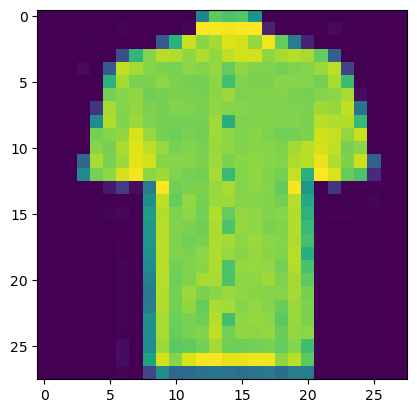

In [58]:
plt.imshow(x_test[40])

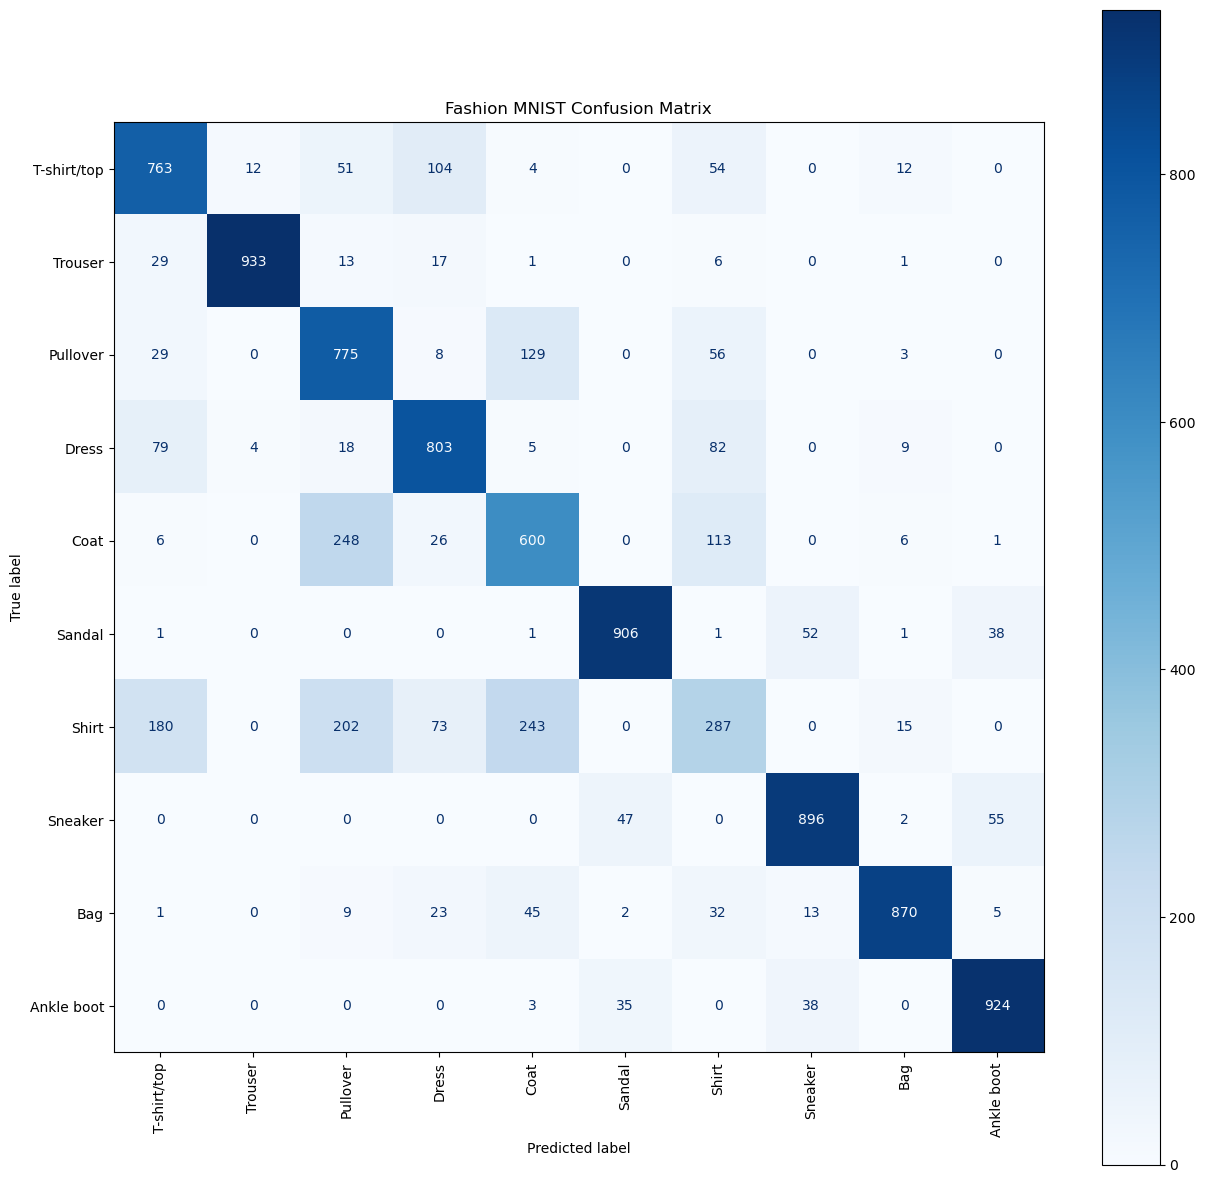

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# 1. Define the correct class names for Fashion MNIST
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# 2. Ensure predictions are converted to integers (if not already)
# y_pred_classes = y_pred.argmax(axis=1)

# 3. Compute Matrix
cm = confusion_matrix(y_test, y_pred_classes)

# 4. Plot with the CORRECT number of labels (10)
fig, ax = plt.subplots(figsize=(15, 15)) # Increased size for readability
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

# Plotting
disp.plot(cmap='Blues', ax=ax, xticks_rotation='vertical') # Added rotation so labels don't overlap

plt.title("Fashion MNIST Confusion Matrix")
plt.show()

In [26]:
y_test.shape

(10000,)

In [27]:
y_pred.shape

(10000, 10)

In [35]:
x_test[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [36]:
x_train[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [62]:
import random

In [ ]:
def plot_random_images(model, images, true_labels, classes):

    i = random.randint(0, len(images))

    # create predicitons and target
    target_image = images[i]
    pred_probs = model.predict(target_image.reshape(1,28,28))
    pred_labels = classes[pred_probs.argmax()]
    true_label = classes[true_labels[i]]

    plt.imshow(target_image, cmap = plt.cm.binary)

    if pred_labels == true_label:
        color='green'
    else:
        color='red'


    # xlable information
    plt.xlabel(f"Pred: {pred_labels}, {100*tf.reduce_max(pred_probs)}, {true_label}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


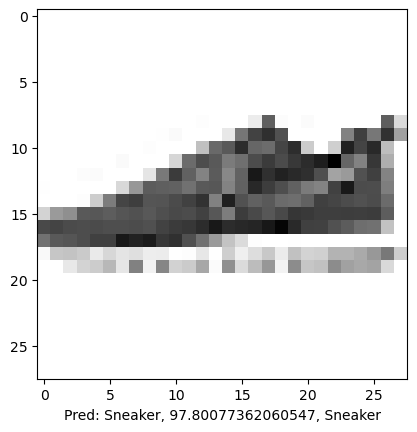

In [77]:
plot_random_images(model3, x_test, y_test, class_names)

In [ ]:
# from sklearn.preprocessing import StandardScaler

# sc = StandardScaler()

# x_train = x_train.reshape(x_train.shape[0],-1) # we need to flattten the [60000,28,28] to [60000,728]
# x_test = x_test.reshape(x_test.shape[0],-1)

# x_train = sc.fit_transform(x_train)
# x_test = sc.transform(x_test)

In [ ]:
# from sklearn.preprocessing import LabelEncoder

# le = LabelEncoder()

# y_train = le.fit_transform(y_train)
# y_test = le.transform(y_test)

In [ ]:
# model = tf.keras.Sequential([
#     tf.keras.layers.Flatten(input_shape=(28,28)),
#     tf.keras.layers.Dense(32, activation='relu'),
#     tf.keras.layers.Dense(32, activation='relu'),
#     tf.keras.layers.Dense(10, activation='softmax')
# ])

# model.compile(optimizer='adam', loss=tf.keras.losses.sparse_categorical_crossentropy, metrics=['accuracy'])

In [ ]:
# model.fit(x_test, epochs=10, batch_size=32, validation_data=(x_test, y_test))